In [7]:
import numpy as np
import pandas as pd
from tqdm import tqdm
import os
import psutil
import time
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from mpl_toolkits.mplot3d import Axes3D
from sklearn.svm import SVR
from sklearn.manifold import TSNE
from sklearn.model_selection import train_test_split
from sklearn.inspection import permutation_importance
from sklearn.preprocessing import LabelEncoder
import torch
import pickle
from torch.nn import Linear
from torch.utils.data import DataLoader
import torch.nn as nn
import torch.nn.functional as F
import concurrent.futures
import warnings
from concurrent.futures import ProcessPoolExecutor
from allensdk.core.brain_observatory_cache import BrainObservatoryCache
from allensdk.brain_observatory.ecephys.ecephys_project_cache import EcephysProjectCache



if torch.cuda.is_available():
    print("CUDA GPU is available.")
    device = torch.device('cuda')
else:
    print("CUDA GPU is not available. Using CPU instead.")
    device = torch.device('cpu')
    
print(f"Current GPU device: {torch.cuda.get_device_name(torch.cuda.current_device())}")
print(f"Total RAM: {(psutil.virtual_memory().total / (1024**3)):.2f} GB")
print(f"Available RAM: {(psutil.virtual_memory().available / (1024**3)):.2f} GB")

CUDA GPU is available.
Current GPU device: NVIDIA A100-PCIE-40GB MIG 2g.10gb
Total RAM: 1006.97 GB
Available RAM: 940.99 GB


In [8]:
from data_processors.data_splitter import DataSplitter
from data_processors.data_splitter_new import DataSplitter as DataSplitter_new
from models.LSTM import train_and_eval
from models.ConsciousLSTM import train_and_eval as conscious_train_and_eval

session_ids = [
    715093703,
    719161530,
    721123822,
    732592105,
    737581020,
    739448407,
    742951821,
    743475441,
    744228101,
    746083955,
    750332458,
    750749662,
    751348571,
    754312389,
    754829445,
    755434585,
    756029989,
    757216464,
    757970808,
    758798717,
    759883607,
    760345702,
    760693773,
    761418226,
    762120172,
    762602078,
    763673393,
    773418906,
    791319847,
    797828357,
    798911424,
    799864342,
]

In [9]:
final_epoch_acc_oldsplit = []

for sid in session_ids:
    print(f"\n=== Training session {sid} ===")
    spike_trains_file_path = f"output/spike_trains_with_stimulus_session_{sid}_5.pkl"
    with open(spike_trains_file_path, "rb") as f:
        spike_df = pickle.load(f)
    data_splitter = DataSplitter(spike_df, time_steps=5, batch_size=64)
    final_epoch_accs = []
    best_epoch_idx, best_val_acc, final_epoch_acc = train_and_eval(
        hidden_dim=1000,
        layer_dim=1,
        learning_rate=0.001,
        num_epochs=9,
        data_splitter=data_splitter,
        validation=False
    )
    final_epoch_acc_oldsplit.append(final_epoch_acc)


=== Training session 715093703 ===
X_val shape: torch.Size([476, 5, 2065])
y_val shape: torch.Size([476])
 
X (array): Matrix of number of batch_size, time_steps_per_frame, num_nodes, and number of features per node.
X.shape = (B, T, N, F)
X_train shape: torch.Size([4284, 5, 2065])
X_test shape: torch.Size([1190, 5, 2065])
X_train type: <class 'torch.Tensor'>
 
X_val shape: torch.Size([476, 5, 2065])
y_val shape: torch.Size([476])
 
y_shape = [batch_size, unique_frames_shown_per_5_timesteps]
y_train shape: torch.Size([4284])
y_test shape: torch.Size([1190])
y_test type: <class 'torch.Tensor'>
 
Epoch 1/9 | Train Acc: 10.78% | Val/Test Acc: 46.22%
Epoch 2/9 | Train Acc: 68.18% | Val/Test Acc: 89.83%
Epoch 3/9 | Train Acc: 82.68% | Val/Test Acc: 93.19%
Epoch 4/9 | Train Acc: 83.26% | Val/Test Acc: 95.21%
Epoch 5/9 | Train Acc: 83.29% | Val/Test Acc: 95.29%
Epoch 6/9 | Train Acc: 83.26% | Val/Test Acc: 95.04%
Epoch 7/9 | Train Acc: 83.29% | Val/Test Acc: 95.04%
Epoch 8/9 | Train Acc: 83.

In [10]:
final_epoch_acc_newsplit = []

for sid in session_ids:
    print(f"\n=== Training session {sid} ===")
    spike_trains_file_path = f"output/spike_trains_with_stimulus_session_{sid}_5.pkl"
    with open(spike_trains_file_path, "rb") as f:
        spike_df = pickle.load(f)
    data_splitter = DataSplitter_new(spike_df, time_steps=5, batch_size=64)
    final_epoch_accs = []
    best_epoch_idx, best_val_acc, final_epoch_acc = train_and_eval(
        hidden_dim=1000,
        layer_dim=1,
        learning_rate=0.001,
        num_epochs=9,
        data_splitter=data_splitter,
        validation=False
    )
    final_epoch_acc_newsplit.append(final_epoch_acc)


=== Training session 715093703 ===
X_train shape: torch.Size([4284, 5, 2065]) | y_train: torch.Size([4284])
X_val   shape: torch.Size([476, 5, 2065])   | y_val:   torch.Size([476])
X_test  shape: torch.Size([1190, 5, 2065])  | y_test:  torch.Size([1190])
(seq_len=5, num_features=2065)
Epoch 1/9 | Train Acc: 14.36% | Val/Test Acc: 45.29%
Epoch 2/9 | Train Acc: 76.82% | Val/Test Acc: 71.68%
Epoch 3/9 | Train Acc: 87.82% | Val/Test Acc: 76.30%
Epoch 4/9 | Train Acc: 88.28% | Val/Test Acc: 78.40%
Epoch 5/9 | Train Acc: 88.33% | Val/Test Acc: 78.82%
Epoch 6/9 | Train Acc: 88.24% | Val/Test Acc: 79.24%
Epoch 7/9 | Train Acc: 88.28% | Val/Test Acc: 79.16%
Epoch 8/9 | Train Acc: 88.38% | Val/Test Acc: 79.41%
Epoch 9/9 | Train Acc: 88.28% | Val/Test Acc: 78.91%
Best epoch: 7 | Best Val Acc: 79.41%

=== Training session 719161530 ===
X_train shape: torch.Size([4284, 5, 1780]) | y_train: torch.Size([4284])
X_val   shape: torch.Size([476, 5, 1780])   | y_val:   torch.Size([476])
X_test  shape: to

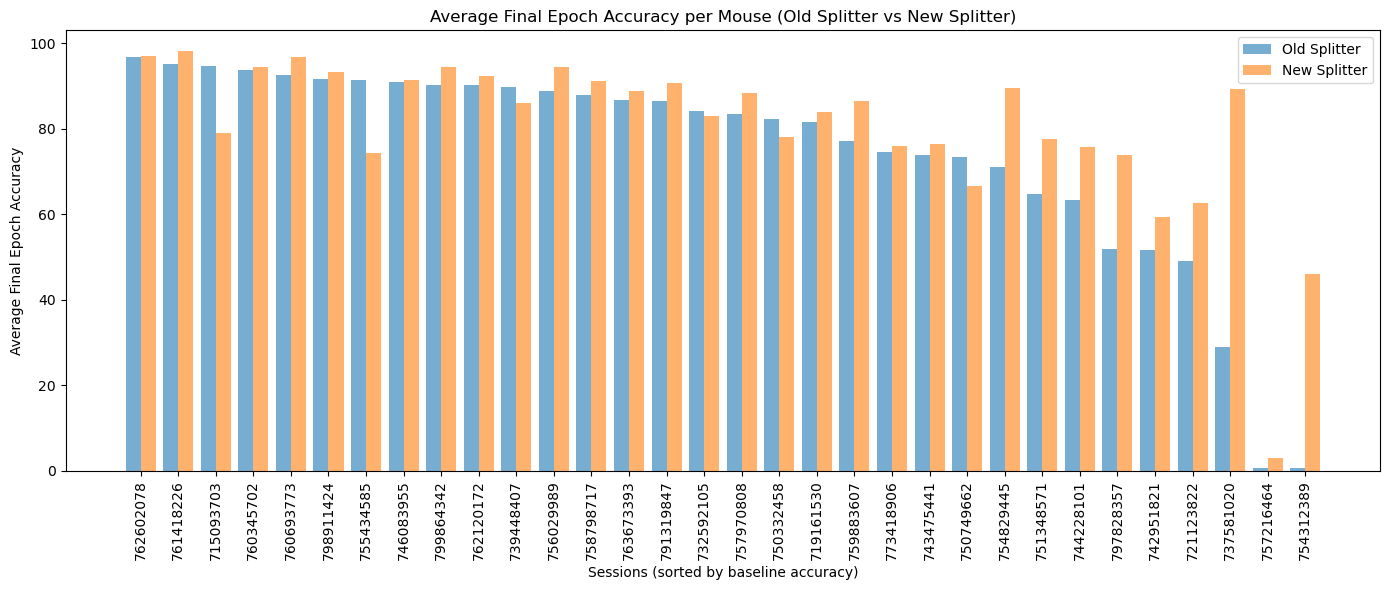

In [11]:
sorted_indices = sorted(
    range(len(session_ids)),
    key=lambda i: final_epoch_acc_oldsplit[i],
    reverse=True
)

oldsplit_sorted   = [final_epoch_acc_oldsplit[i] for i in sorted_indices]
newsplit_sorted  = [final_epoch_acc_newsplit[i] for i in sorted_indices]
x = np.arange(len(oldsplit_sorted))
width = 0.4
plt.figure(figsize=(14, 6))

plt.bar(
    x - width/2,
    oldsplit_sorted,
    width=width,
    alpha=0.6,
    label="Old Splitter",
)
plt.bar(
    x + width/2,
    newsplit_sorted,
    width=width,
    alpha=0.6,
    label="New Splitter",
)
session_labels = [session_ids[i] for i in sorted_indices]

plt.xticks(x, session_labels, rotation=90)
plt.xlabel("Sessions (sorted by baseline accuracy)")
plt.ylabel("Average Final Epoch Accuracy")
plt.title("Average Final Epoch Accuracy per Mouse (Old Splitter vs New Splitter)")
plt.legend()
plt.tight_layout()
plt.show()

In [12]:
avg1 = sum(final_epoch_acc_oldsplit) / len(final_epoch_acc_oldsplit)
avg2 = sum(final_epoch_acc_newsplit) / len(final_epoch_acc_newsplit)
difference = avg2 - avg1

print(f"Old Splitter accs: {final_epoch_acc_newsplit}\n")
print(f"New Splitter accs: {final_epoch_acc_oldsplit}\n")
print(f"New Splitter avg acc - Old Splitter avg acc: {difference}")

Old Splitter accs: [78.90756302521008, 83.94957983193278, 62.6890756302521, 82.94117647058825, 89.26458157227388, 85.96638655462185, 59.32773109243698, 76.38655462184873, 75.7983193277311, 91.42857142857143, 78.0672268907563, 66.47058823529412, 77.56302521008404, 46.05042016806723, 89.49579831932773, 74.36974789915966, 94.45378151260503, 3.0252100840336134, 88.31932773109243, 91.17647058823529, 86.5546218487395, 94.45378151260503, 96.63865546218487, 98.0672268907563, 92.26890756302521, 97.05882352941177, 88.73949579831933, 75.88235294117646, 90.67226890756302, 73.8655462184874, 93.27731092436974, 94.45378151260503]

New Splitter accs: [94.62184873949579, 81.59663865546219, 49.159663865546214, 84.03361344537815, 28.849407783417934, 89.74789915966387, 51.59663865546219, 73.8655462184874, 63.27731092436974, 90.84033613445378, 82.18487394957982, 73.27731092436974, 64.70588235294117, 0.5882352941176471, 71.09243697478992, 91.42857142857143, 88.8235294117647, 0.7563025210084033, 83.361344537

In [20]:
for sid in session_labels:
    spike_trains_file_path = f'output/spike_trains_with_stimulus_session_{sid}_5.pkl'
    with open(spike_trains_file_path, 'rb') as f:
        spike_df = pickle.load(f)

    #print(f'{sid} rows /5*118: {spike_df.shape[0]}')
    #print(f'{sid} rows /5*118: {spike_df.shape[0]/(5*118)}')
    print(f'{sid} rows mod 25: {spike_df.shape[0]%25}')
    #print(f'{sid} rows mod 250: {spike_df.shape[0]%250}')

762602078 rows mod 25: 0
715093703 rows mod 25: 0
761418226 rows mod 25: 0
760345702 rows mod 25: 0
760693773 rows mod 25: 0
798911424 rows mod 25: 0
746083955 rows mod 25: 0
799864342 rows mod 25: 0
739448407 rows mod 25: 0
762120172 rows mod 25: 0
755434585 rows mod 25: 0
756029989 rows mod 25: 0
758798717 rows mod 25: 0
763673393 rows mod 25: 0
791319847 rows mod 25: 0
732592105 rows mod 25: 0
750332458 rows mod 25: 0
757970808 rows mod 25: 0
719161530 rows mod 25: 0
759883607 rows mod 25: 0
743475441 rows mod 25: 0
773418906 rows mod 25: 0
750749662 rows mod 25: 0
754829445 rows mod 25: 0
744228101 rows mod 25: 0
751348571 rows mod 25: 0
797828357 rows mod 25: 0
742951821 rows mod 25: 0
721123822 rows mod 25: 0
737581020 rows mod 25: 10
754312389 rows mod 25: 0
757216464 rows mod 25: 0


In [19]:
from collections import Counter

seq_len = 5
overall_counts = Counter()

for sid in session_ids:
    path = f"output/spike_trains_with_stimulus_session_{sid}_5.pkl"
    with open(path, "rb") as f:
        df = pickle.load(f)

    # Last column is the frame label
    frames = df.iloc[:, -1].to_numpy()
    row_counts = Counter(frames)

    # Convert row counts → exposure counts (one exposure = 5 rows)
    session_counts = {}
    for frame, c in row_counts.items():
        # Optional sanity check
        if c % seq_len != 0:
            print(f"WARNING: frame {frame} in session {sid} has {c} rows (not multiple of {seq_len})")
        session_counts[frame] = c // seq_len

    print(f"\nSession {sid} — exposures per frame label:")
    for frame in sorted(session_counts):
        print(f"  frame {frame}: {session_counts[frame]} exposures")

    overall_counts.update(session_counts)

print("\n=== Total exposures across all sessions ===")
for frame in sorted(overall_counts):
    print(f"frame {frame}: {overall_counts[frame]} exposures")

print(f"\nTotal distinct frame labels observed: {len(overall_counts)}")


Session 715093703 — exposures per frame label:
  frame -1.0: 50 exposures
  frame 0.0: 50 exposures
  frame 1.0: 50 exposures
  frame 2.0: 50 exposures
  frame 3.0: 50 exposures
  frame 4.0: 50 exposures
  frame 5.0: 50 exposures
  frame 6.0: 50 exposures
  frame 7.0: 50 exposures
  frame 8.0: 50 exposures
  frame 9.0: 50 exposures
  frame 10.0: 50 exposures
  frame 11.0: 50 exposures
  frame 12.0: 50 exposures
  frame 13.0: 50 exposures
  frame 14.0: 50 exposures
  frame 15.0: 50 exposures
  frame 16.0: 50 exposures
  frame 17.0: 50 exposures
  frame 18.0: 50 exposures
  frame 19.0: 50 exposures
  frame 20.0: 50 exposures
  frame 21.0: 50 exposures
  frame 22.0: 50 exposures
  frame 23.0: 50 exposures
  frame 24.0: 50 exposures
  frame 25.0: 50 exposures
  frame 26.0: 50 exposures
  frame 27.0: 50 exposures
  frame 28.0: 50 exposures
  frame 29.0: 50 exposures
  frame 30.0: 50 exposures
  frame 31.0: 50 exposures
  frame 32.0: 50 exposures
  frame 33.0: 50 exposures
  frame 34.0: 50 

In [14]:
for sid in session_ids:
    spike_trains_file_path = f'output/spike_trains_with_stimulus_session_{sid}_5.pkl'
    with open(spike_trains_file_path, 'rb') as f:
        spike_df = pickle.load(f)

    print(f'{sid} rows mod 5: {spike_df.shape[0]%5}')

715093703 rows mod 5: 0
719161530 rows mod 5: 0
721123822 rows mod 5: 0
732592105 rows mod 5: 0
737581020 rows mod 5: 0
739448407 rows mod 5: 0
742951821 rows mod 5: 0
743475441 rows mod 5: 0
744228101 rows mod 5: 0
746083955 rows mod 5: 0
750332458 rows mod 5: 0
750749662 rows mod 5: 0
751348571 rows mod 5: 0
754312389 rows mod 5: 0
754829445 rows mod 5: 0
755434585 rows mod 5: 0
756029989 rows mod 5: 0
757216464 rows mod 5: 0
757970808 rows mod 5: 0
758798717 rows mod 5: 0
759883607 rows mod 5: 0
760345702 rows mod 5: 0
760693773 rows mod 5: 0
761418226 rows mod 5: 0
762120172 rows mod 5: 0
762602078 rows mod 5: 0
763673393 rows mod 5: 0
773418906 rows mod 5: 0
791319847 rows mod 5: 0
797828357 rows mod 5: 0
798911424 rows mod 5: 0
799864342 rows mod 5: 0


In [16]:
final_epoch_acc_oldsplitcln = []

for sid in session_ids:
    print(f"\n=== Training session {sid} ===")
    spike_trains_file_path = f"output/spike_trains_with_stimulus_session_{sid}_5.pkl"
    with open(spike_trains_file_path, "rb") as f:
        spike_df = pickle.load(f)

    spike_df = spike_df[spike_df.iloc[:, -1] != -1]

    data_splitter = DataSplitter(spike_df, time_steps=5, batch_size=64)
    final_epoch_accs = []
    best_epoch_idx, best_val_acc, final_epoch_acc = train_and_eval(
        hidden_dim=1000,
        layer_dim=1,
        learning_rate=0.001,
        num_epochs=9,
        data_splitter=data_splitter,
        validation=False
    )
    final_epoch_acc_oldsplitcln.append(final_epoch_acc)


=== Training session 715093703 ===
X_val shape: torch.Size([472, 5, 2065])
y_val shape: torch.Size([472])
 
X (array): Matrix of number of batch_size, time_steps_per_frame, num_nodes, and number of features per node.
X.shape = (B, T, N, F)
X_train shape: torch.Size([4248, 5, 2065])
X_test shape: torch.Size([1180, 5, 2065])
X_train type: <class 'torch.Tensor'>
 
X_val shape: torch.Size([472, 5, 2065])
y_val shape: torch.Size([472])
 
y_shape = [batch_size, unique_frames_shown_per_5_timesteps]
y_train shape: torch.Size([4248])
y_test shape: torch.Size([1180])
y_test type: <class 'torch.Tensor'>
 
Epoch 1/9 | Train Acc: 11.06% | Val/Test Acc: 42.12%
Epoch 2/9 | Train Acc: 66.60% | Val/Test Acc: 87.20%
Epoch 3/9 | Train Acc: 82.70% | Val/Test Acc: 92.54%
Epoch 4/9 | Train Acc: 83.15% | Val/Test Acc: 95.59%
Epoch 5/9 | Train Acc: 83.22% | Val/Test Acc: 95.34%
Epoch 6/9 | Train Acc: 83.22% | Val/Test Acc: 95.59%
Epoch 7/9 | Train Acc: 83.29% | Val/Test Acc: 95.42%
Epoch 8/9 | Train Acc: 83.

In [21]:
final_epoch_acc_newsplitcln = []

for sid in session_ids:
    print(f"\n=== Training session {sid} ===")
    spike_trains_file_path = f"output/spike_trains_with_stimulus_session_{sid}_5.pkl"
    with open(spike_trains_file_path, "rb") as f:
        spike_df = pickle.load(f)

    spike_df = spike_df[spike_df.iloc[:, -1] != -1]

    data_splitter = DataSplitter_new(spike_df, time_steps=5, batch_size=64)
    final_epoch_accs = []
    best_epoch_idx, best_val_acc, final_epoch_acc = train_and_eval(
        hidden_dim=1000,
        layer_dim=1,
        learning_rate=0.001,
        num_epochs=9,
        data_splitter=data_splitter,
        validation=False
    )
    final_epoch_acc_newsplitcln.append(final_epoch_acc)


=== Training session 715093703 ===
X_train shape: torch.Size([4248, 5, 2065]) | y_train: torch.Size([4248])
X_val   shape: torch.Size([472, 5, 2065])   | y_val:   torch.Size([472])
X_test  shape: torch.Size([1180, 5, 2065])  | y_test:  torch.Size([1180])
(seq_len=5, num_features=2065)
Epoch 1/9 | Train Acc: 12.90% | Val/Test Acc: 37.46%
Epoch 2/9 | Train Acc: 74.13% | Val/Test Acc: 71.27%
Epoch 3/9 | Train Acc: 87.66% | Val/Test Acc: 77.03%
Epoch 4/9 | Train Acc: 88.42% | Val/Test Acc: 78.47%
Epoch 5/9 | Train Acc: 88.35% | Val/Test Acc: 78.64%
Epoch 6/9 | Train Acc: 88.42% | Val/Test Acc: 79.07%
Epoch 7/9 | Train Acc: 88.30% | Val/Test Acc: 79.15%
Epoch 8/9 | Train Acc: 88.44% | Val/Test Acc: 79.07%
Epoch 9/9 | Train Acc: 88.39% | Val/Test Acc: 79.24%
Best epoch: 8 | Best Val Acc: 79.24%

=== Training session 719161530 ===
X_train shape: torch.Size([4248, 5, 1780]) | y_train: torch.Size([4248])
X_val   shape: torch.Size([472, 5, 1780])   | y_val:   torch.Size([472])
X_test  shape: to

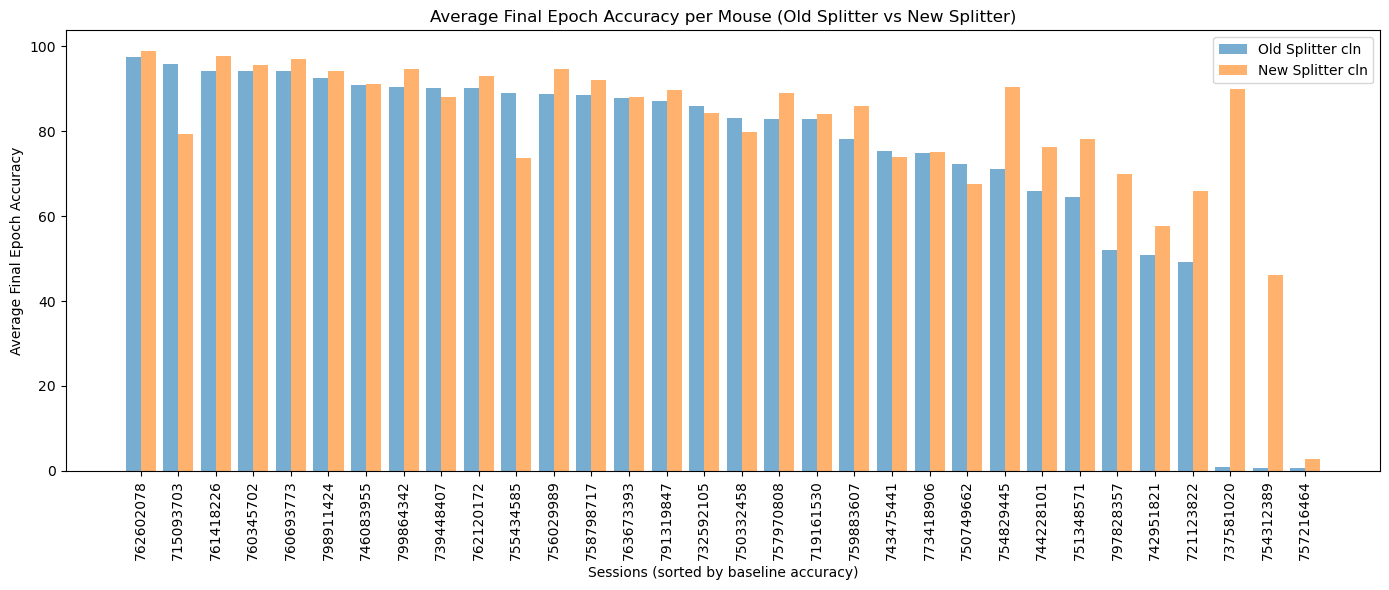

In [22]:
sorted_indicescln = sorted(
    range(len(session_ids)),
    key=lambda i: final_epoch_acc_oldsplitcln[i],
    reverse=True
)

oldsplit_sortedcln   = [final_epoch_acc_oldsplitcln[i] for i in sorted_indicescln]
newsplit_sortedcln  = [final_epoch_acc_newsplitcln[i] for i in sorted_indicescln]
x = np.arange(len(oldsplit_sortedcln))
width = 0.4
plt.figure(figsize=(14, 6))

plt.bar(
    x - width/2,
    oldsplit_sortedcln,
    width=width,
    alpha=0.6,
    label="Old Splitter cln",
)
plt.bar(
    x + width/2,
    newsplit_sortedcln,
    width=width,
    alpha=0.6,
    label="New Splitter cln",
)
session_labels = [session_ids[i] for i in sorted_indicescln]

plt.xticks(x, session_labels, rotation=90)
plt.xlabel("Sessions (sorted by baseline accuracy)")
plt.ylabel("Average Final Epoch Accuracy")
plt.title("Average Final Epoch Accuracy per Mouse (Old Splitter vs New Splitter)")
plt.legend()
plt.tight_layout()
plt.show()